# Feature Space of the LSTM Classifier

In <a href=".5.LSTMClassifier.ipynb">5.LSTMClassifier.ipynb</a>, we trained a LSTM Classifier on developed markets which had sufficiently good out-of-the-box performance on emerging markets. In fact, the fine-tuning experiment that was able to surpass this was a complete retrain of the model on emerging markets data. Here we explore what the feature space of the original model looks like and how it separates the positive from the negative classes and organizes the different markets across the train and test periods.

In [1]:
from src.model.utilities import set_seed, set_device
seed = set_seed()
device = set_device()

from src.features.utilities import load_or_train_model

import pandas as pd
import numpy as np

import os
import dotenv
dotenv.load_dotenv()
username = os.getenv("HUGGINGFACE_USERNAME")

No GPU available! Running on CPU


In [2]:
from datasets import load_dataset
from src.data.data_utilities import build_labels

# download monthly resolution data
datalink = f"{username}/imputed-monthly"
train_df = load_dataset(datalink, "developed", split='train').to_pandas()
test_df = load_dataset(datalink, "developed", split='test').to_pandas()
support_df = load_dataset(datalink, "emerging", split='train').to_pandas()
query_df = load_dataset(datalink, "emerging", split='test').to_pandas()

support_countries = ['Brazil', 'Chile', 'China', 'Colombia', 'Costa Rica', 'India', 'Indonesia', 'Mexico', 'South Africa', 'Turkey']

# build crisis labels
y_train = build_labels(train_df)
y_test = build_labels(test_df)
y_support = build_labels(support_df)
y_query = build_labels(query_df)

Model type: <class 'src.model.architectures.LSTMClassifier'>


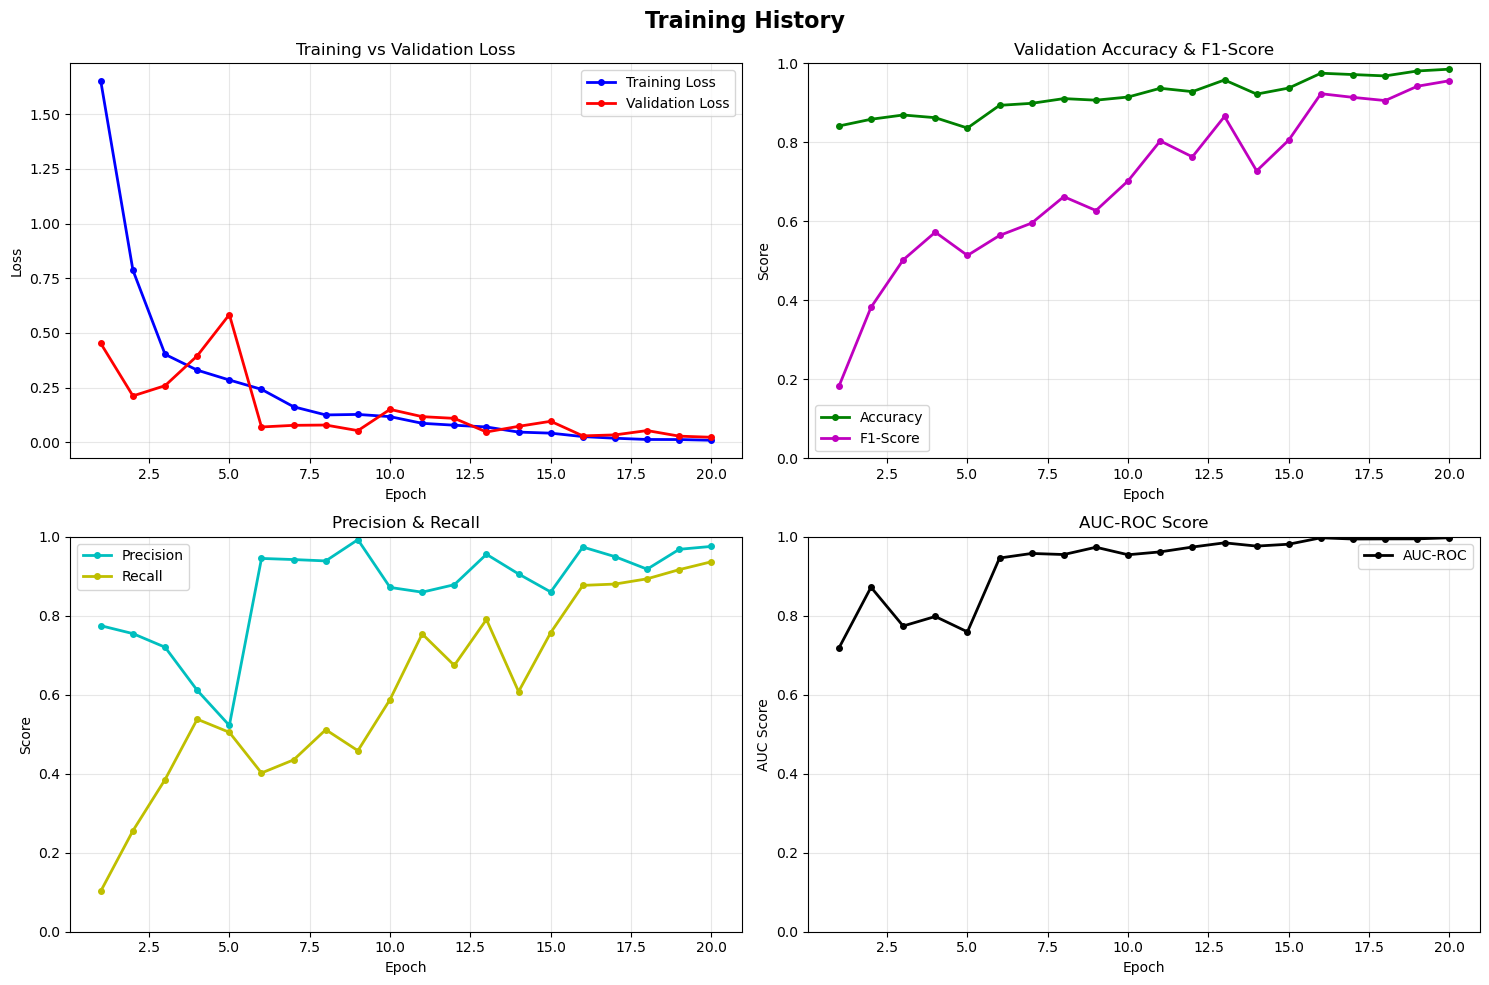

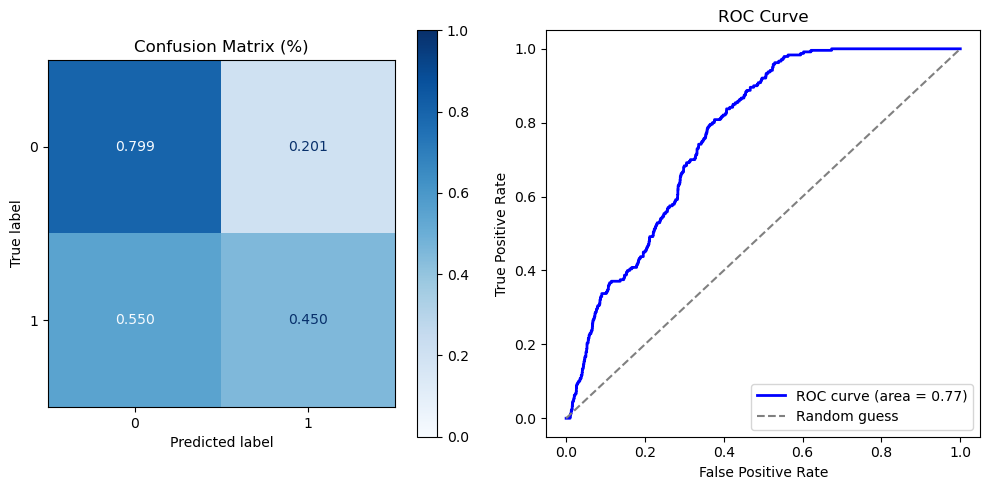

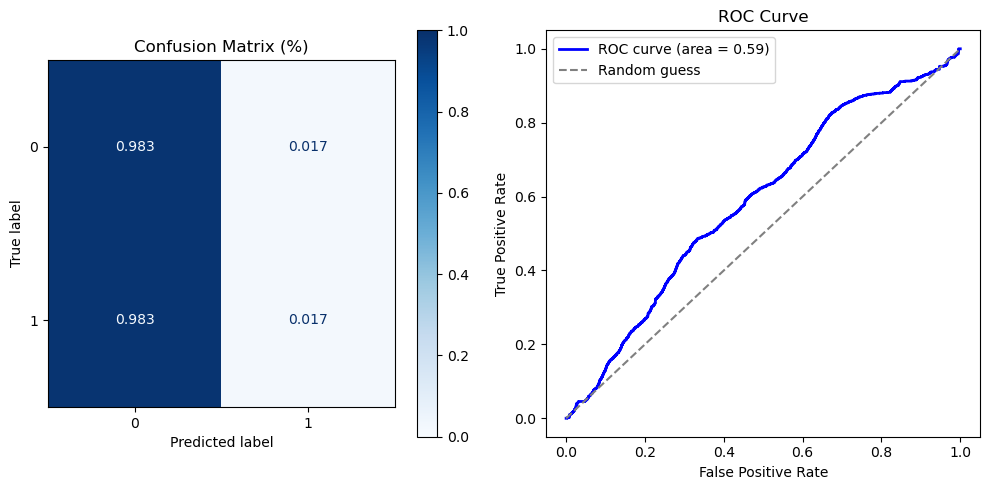

In [3]:
from src.model.architectures import LSTMClassifier
from src.model.loss import PrecisionFocalLoss
from src.model.classifiers import plot_metrics
from src.features.utilities import load_or_train_model
from src.model.utilities import plot_training_history

# choose LSTM Classifier parameters
params = {
    'sequence_length': 48,
    'lstm_units': 128,
    'num_lstm_layers': 3,
    'dense_units': [128, 64],
    'learning_rate': 8e-4,
    'batch_size': 64,
    'dropout_rate': 0.15,
    'n_epochs': 20,
    'use_attention': True,
    'use_residual': True,
    'Gaussian_noise': False,
    'noise_factor': 0.0,
    'criterion': PrecisionFocalLoss(alpha=0.1, gamma=2.0, precision_weight=2.25)
}

# train or load LSTM classifier
lstm_classifier = load_or_train_model(
    model_class=LSTMClassifier,
    params=params,
    train_data=train_df,
    train_labels=y_train,
    force_retrain=False
)
# plot training history
print(f"Model type: {type(lstm_classifier)}")
plot_training_history(lstm_classifier.train_losses, lstm_classifier.val_losses, lstm_classifier.val_metrics_history)

# test_df: add last sequence_length-1 of train data to test data for each Country
indices = len(train_df['Country'].unique())*(params['sequence_length']-1)
add_df = train_df.sort_values('Date')[-indices:]
add_test_df = pd.concat([add_df, test_df], ignore_index=True)
y_test_extended = build_labels(add_test_df)

# query_df: add last sequence_length-1 of support data to query data for each Country
indices = len(support_df['Country'].unique())*(params['sequence_length']-1)
add_df = support_df.sort_values('Date')[-indices:]
add_query_df = pd.concat([add_df, query_df], ignore_index=True)
y_query_extended = build_labels(add_query_df)

# plot confusion matrix and AUC-ROC for test sets
plot_metrics(lstm_classifier, add_test_df, y_test_extended)
plot_metrics(lstm_classifier, add_query_df, y_query_extended)

In [4]:
from src.model.dataset import SequentialDataset
from torch.utils.data import DataLoader

# now we create dataloaders for each of the datasets we want to visualize in the embedding space

# developed markets train
train_dataset = SequentialDataset(
    train_df=train_df,
    y_train=y_train,
    sequence_length=params['sequence_length'],
    fit_scaler=True
)
train_loader = DataLoader(
    train_dataset,
    batch_size=params['batch_size'],
    shuffle=False
)

# developed markets test
val_dataset = SequentialDataset(
    train_df=add_test_df,
    y_train=y_test_extended,
    sequence_length=params['sequence_length'],
    scaler=train_dataset.scaler,
    fit_scaler=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=params['batch_size'],
    shuffle=False
)

# emerging markets test
query_dataset = SequentialDataset(
    train_df=add_query_df,
    y_train=y_query_extended,
    sequence_length=params['sequence_length'],
    scaler=train_dataset.scaler,
    fit_scaler=False
)
query_loader = DataLoader(
    query_dataset,
    batch_size=params['batch_size'],
    shuffle=False
)

In [5]:
import pandas as pd
from src.model.utilities import extract_embedding
from src.features.umap import BaseUMAP

# for each dataloader, extract embeddings of the trained LSTM Classifier
train_embeddings, _ = extract_embedding(lstm_classifier, train_loader, device)
test_embeddings, _ = extract_embedding(lstm_classifier, val_loader, device)
query_embeddings, _ = extract_embedding(lstm_classifier, query_loader, device)

# get the valid indices and aligned labels for each dataset
train_valid_indices = train_dataset.get_valid_indices()
val_valid_indices = val_dataset.get_valid_indices()
query_valid_indices = query_dataset.get_valid_indices()

# get the corresponding labels using the valid indices
y_train_aligned = y_train[train_valid_indices]
y_test_aligned = y_test_extended[val_valid_indices]
y_query_aligned = y_query_extended[query_valid_indices]

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Train labels shape: {y_train_aligned.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")
print(f"Test labels shape: {y_test_aligned.shape}")
print(f"Query embeddings shape: {query_embeddings.shape}")
print(f"Query labels shape: {y_query_aligned.shape}")

Train embeddings shape: (8789, 64)
Train labels shape: (8789,)
Test embeddings shape: (3468, 64)
Test labels shape: (3468,)
Query embeddings shape: (14892, 64)
Query labels shape: (14892,)


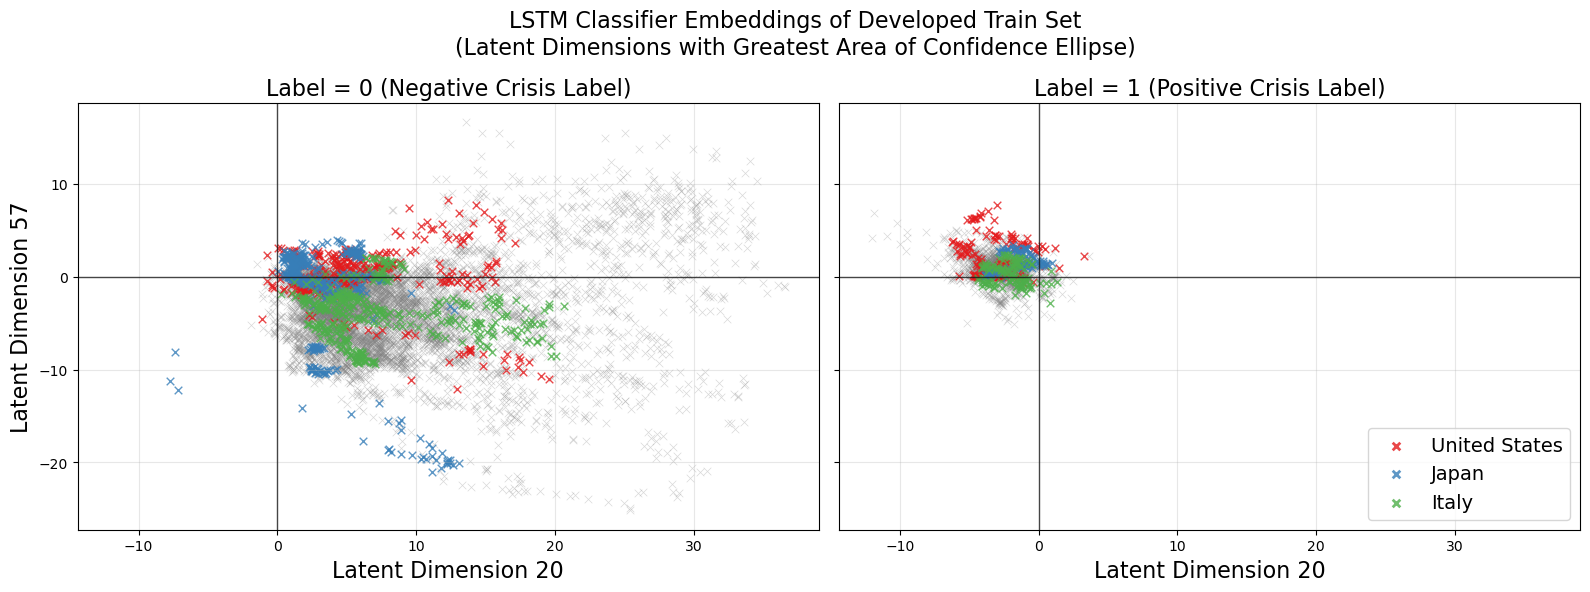

In [6]:
from src.features.pca import BasePCA
import pandas as pd

# use BasePCA to visualize the embeddings in 2D space
# (note, we do not fit a PCA on the embeddings, we just use it to select the top 2 dimensions with greatest variance)
base = BasePCA(n_components = train_embeddings.shape[1])

# developed markets train
embeddings_df = base.to_dataframe(
    transformed_data = train_embeddings,
    index = pd.Index(train_valid_indices),
    column_prefix = 'Latent Dimension ')
dim1, dim2 = base.plot_feature_space(
    embeddings_df, labels=y_train_aligned,
    color_by=train_df['Country'].iloc[train_valid_indices],
    highlight_categories=['United States', 'Japan', 'Italy'],
    title="LSTM Classifier Embeddings of Developed Train Set\n(Latent Dimensions with Greatest Area of Confidence Ellipse)",
)

In [7]:
dim1, dim2

(19, 56)

In [8]:
# Get a slice of embeddings_df corresponding to the chosen dimensions
selected_embeddings = embeddings_df.iloc[:, [dim1, dim2]]

print(f"Selected dimensions: {dim1} and {dim2}")
print(f"Original embeddings shape: {embeddings_df.shape}")
print(f"Selected embeddings shape: {selected_embeddings.shape}")
print(f"Selected column names: {selected_embeddings.columns.tolist()}")

# Show first few rows
print("\nFirst 5 rows of selected embeddings:")
print(selected_embeddings.head())

Selected dimensions: 19 and 56
Original embeddings shape: (8789, 64)
Selected embeddings shape: (8789, 2)
Selected column names: ['Latent Dimension 20', 'Latent Dimension 57']

First 5 rows of selected embeddings:
    Latent Dimension 20  Latent Dimension 57
47            -5.127502            -5.012932
48            -1.906972            -5.226289
49            -0.159055            -6.024351
50             3.826029            -8.079763
51             6.357478            -8.144972


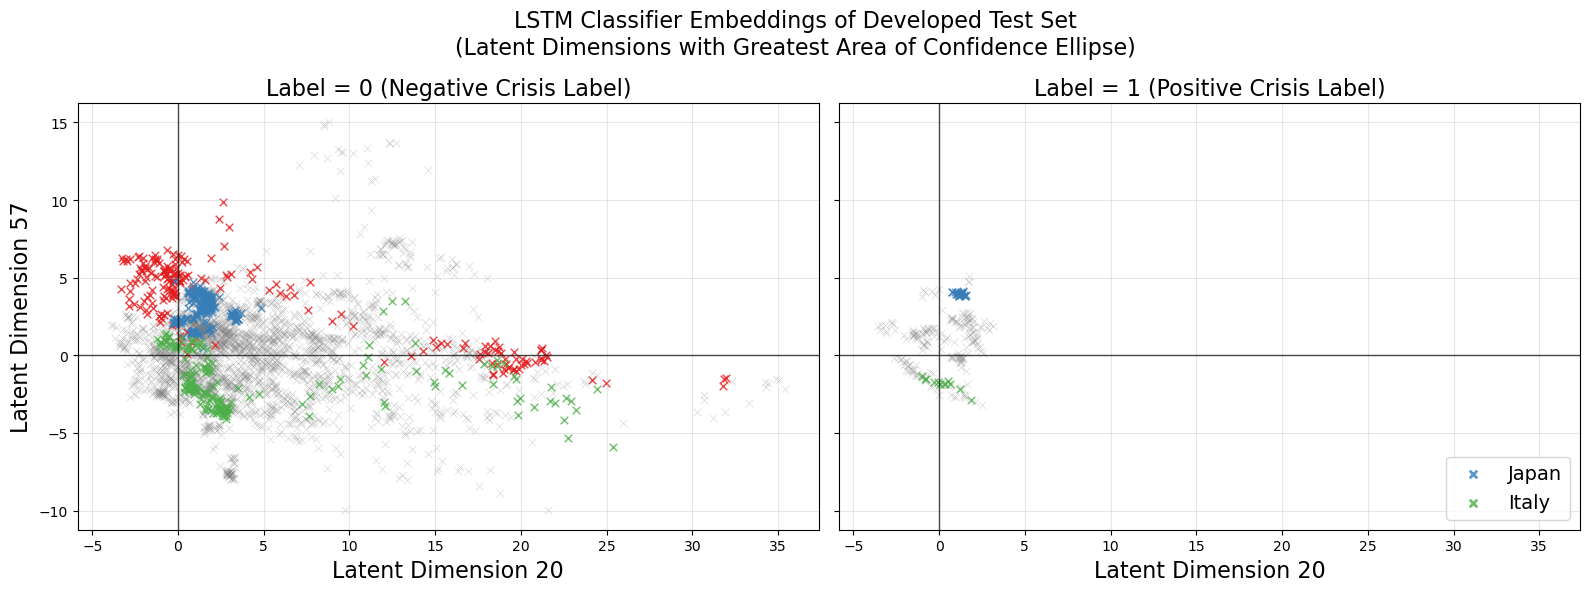

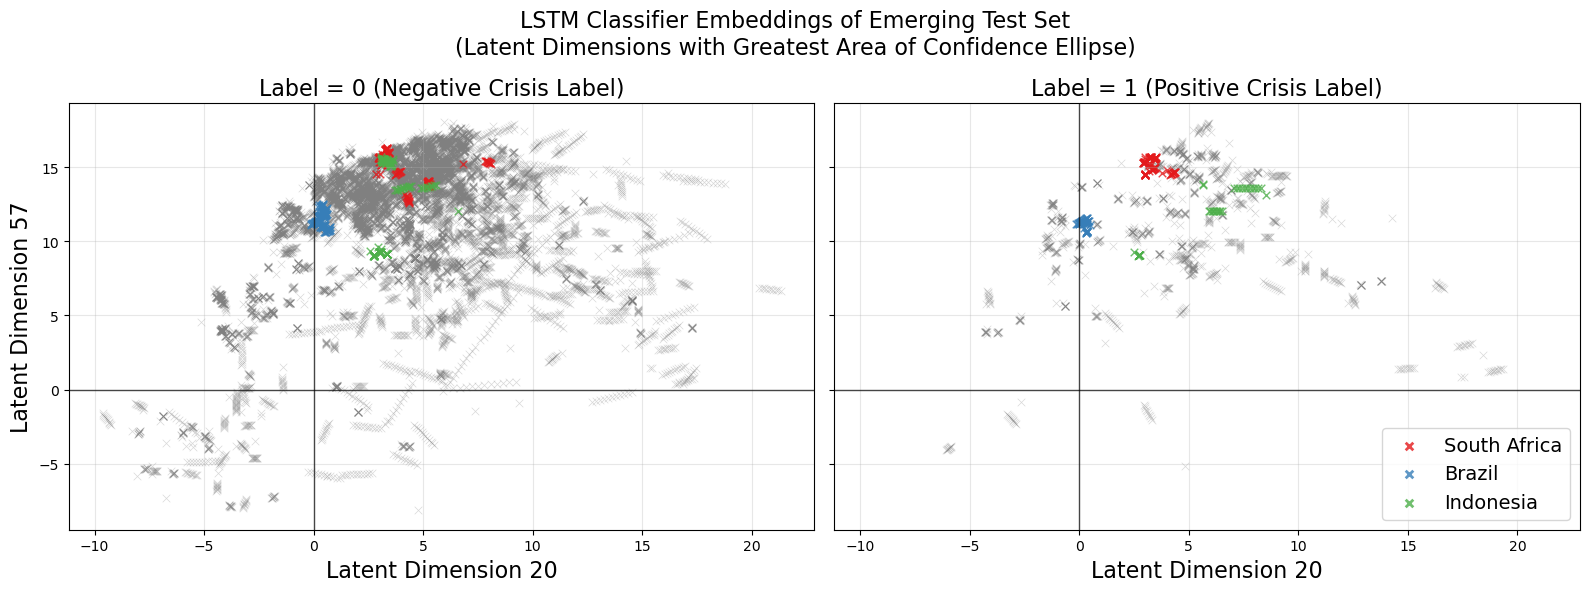

In [9]:
# developed markets test
embeddings_df = base.to_dataframe(
    transformed_data = test_embeddings,
    index = pd.Index(val_valid_indices),
    column_prefix = 'Latent Dimension ')

_, _ = base.plot_feature_space(
    embeddings_df.iloc[:, [dim1, dim2]], labels=y_test_aligned,
    color_by=add_test_df['Country'].iloc[val_valid_indices],
    highlight_categories=['United States', 'Japan', 'Italy'],
    title="LSTM Classifier Embeddings of Developed Test Set\n(Latent Dimensions with Greatest Area of Confidence Ellipse)",
)

# emerging markets test
embeddings_df = base.to_dataframe(
    transformed_data = query_embeddings,
    index = pd.Index(query_valid_indices),
    column_prefix = 'Latent Dimension ')
_, _ = base.plot_feature_space(
    embeddings_df.iloc[:, [dim1, dim2]], labels=y_query_aligned,
    color_by=add_query_df['Country'].iloc[query_valid_indices],
    highlight_categories=['South Africa', 'Brazil', 'Indonesia'],
    title="LSTM Classifier Embeddings of Emerging Test Set\n(Latent Dimensions with Greatest Area of Confidence Ellipse)",
)

We can also fit a UMAP to the extracted embeddings to visualize an alternative interpretation of the feature space. This creates more obvious clusters but they do not appear to be very meaningful.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


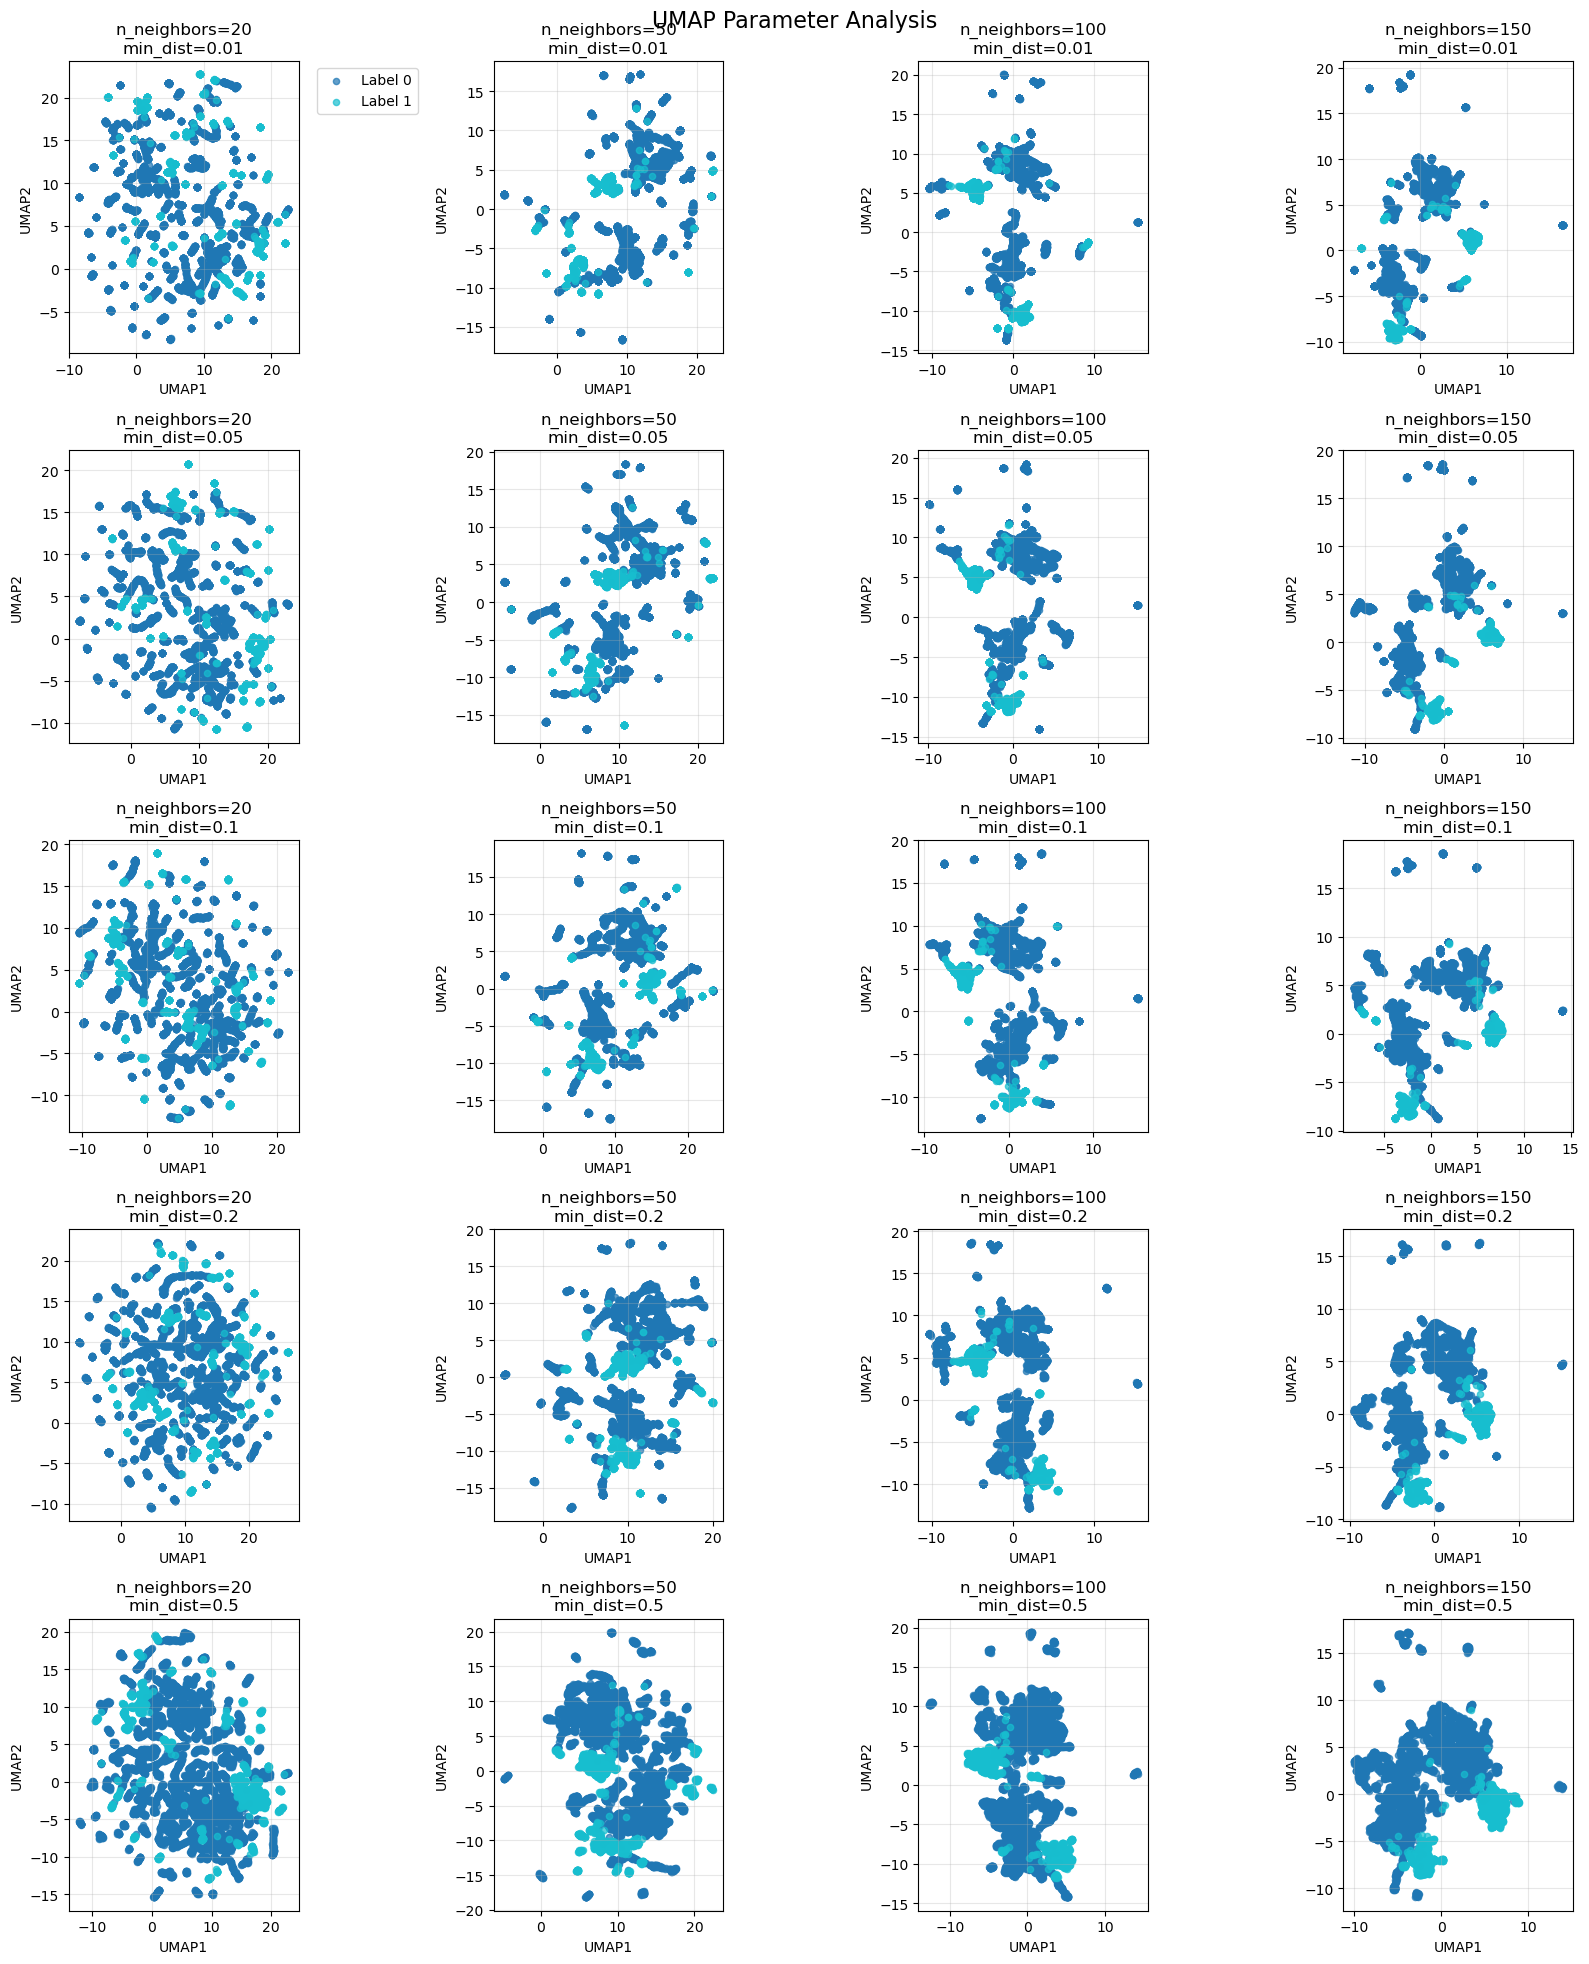

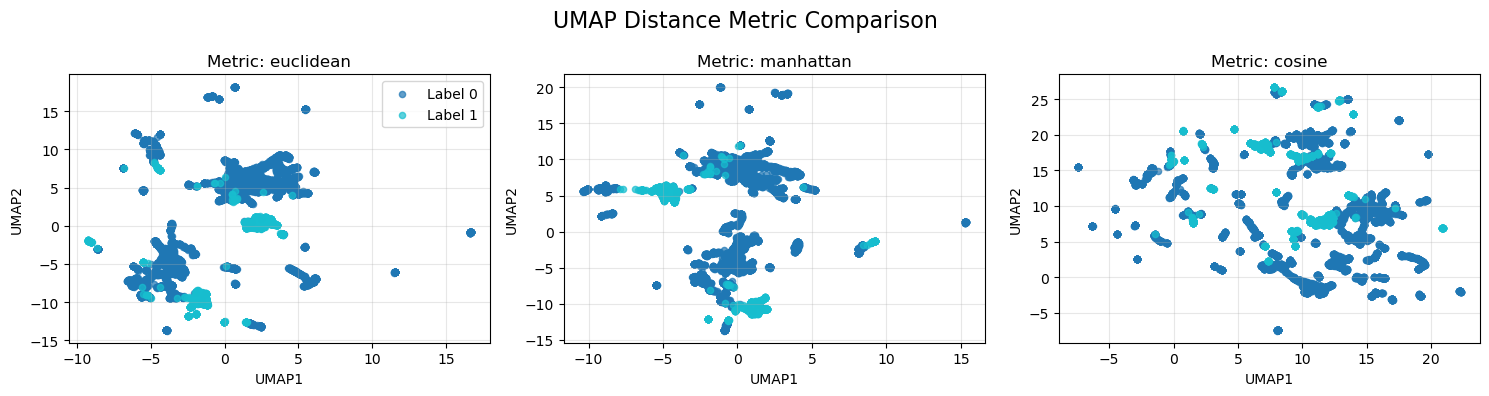

In [7]:
umap_unsupervised = BaseUMAP(n_components=2,
                             pca_preprocess=False,
                             supervised=False,
                             n_neighbors=100,
                             min_dist=0.01,
                             metric='manhattan')
# explore parameter ranges
umap_unsupervised.plot_parameter_analysis(
    pd.DataFrame(train_embeddings), y_train_aligned,
    n_neighbors_range=[20, 50, 100, 150],
    min_dist_range=[0.01, 0.05, 0.1, 0.2, 0.5]
)

umap_unsupervised.plot_metric_comparison(
    pd.DataFrame(train_embeddings), y_train_aligned,
    # explore different metrics
    metrics=['euclidean', 'manhattan', 'cosine']
)

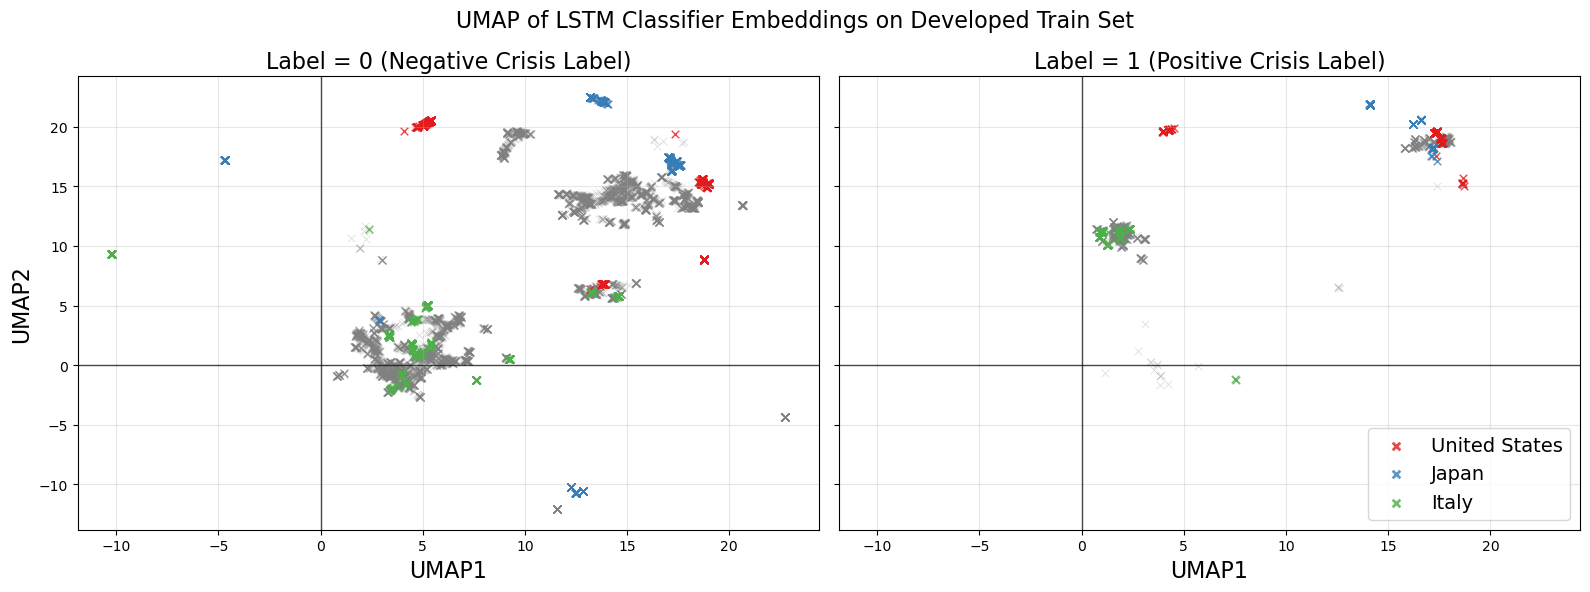

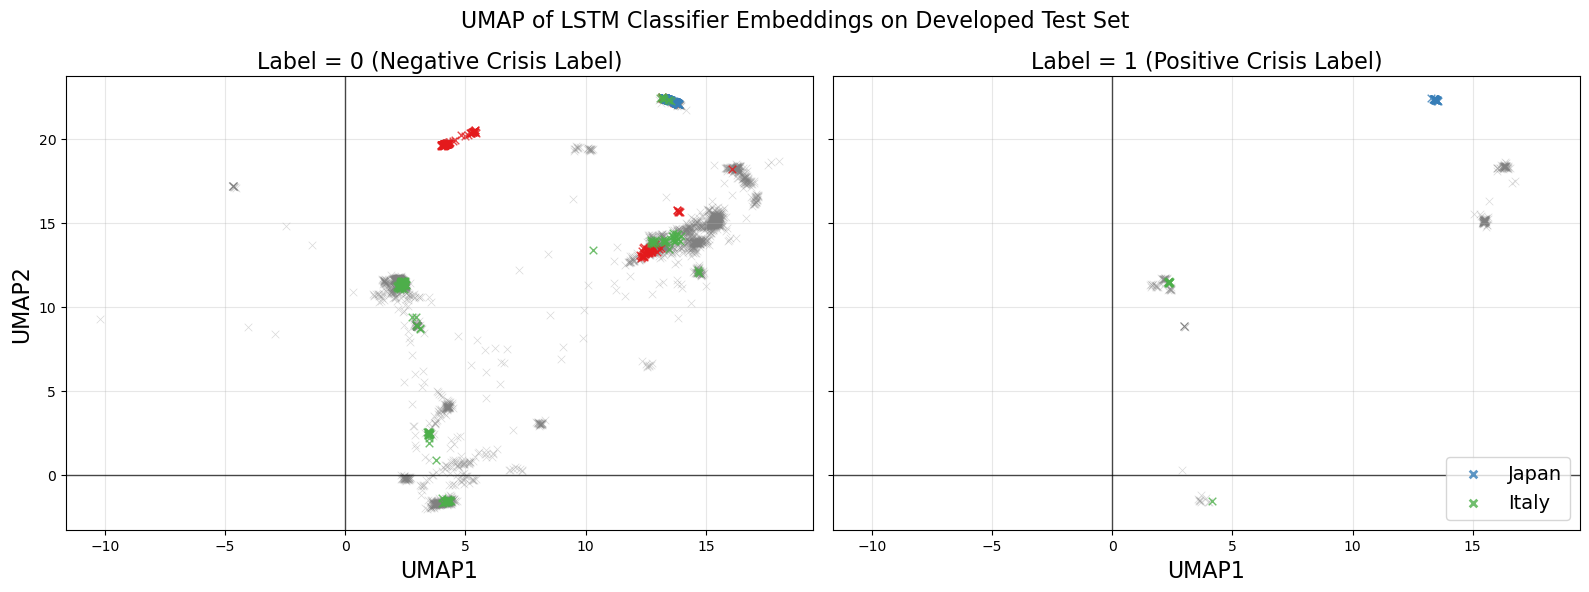

In [ ]:
iso = load_dataset(f"{username}/iso-standard-master", split='train').to_pandas()

# train best UMAP on feature space
umap_unsupervised = BaseUMAP(n_components=2,
                             pca_preprocess=False,
                             supervised=False,
                             n_neighbors=100,
                             min_dist=0.01,
                             metric='euclidean')
umap_unsupervised.fit(pd.DataFrame(train_embeddings), y_train_aligned)

# visualize developed markets train embeddings
umap_train_embeddings = umap_unsupervised.transform(pd.DataFrame(train_embeddings))
train_region = pd.merge(train_df, iso, left_on='Country', right_on='name', how='left')

train_color_by = train_region['Country'].iloc[train_valid_indices].reset_index(drop=True)

umap_unsupervised.plot_feature_space(
    pd.DataFrame(umap_train_embeddings), labels=y_train_aligned,
    color_by=train_color_by,
    highlight_categories=['United States', 'Japan', 'Italy'],
    title="UMAP of LSTM Classifier Embeddings on Developed Train Set",
)

# visualize developed markets test embeddings
umap_test_embeddings = umap_unsupervised.transform(pd.DataFrame(test_embeddings))

test_region = pd.merge(add_test_df, iso, left_on='Country', right_on='name', how='left')
test_color_by = test_region['Country'].iloc[val_valid_indices].reset_index(drop=True)

umap_unsupervised.plot_feature_space(
    pd.DataFrame(umap_test_embeddings), labels=y_test_aligned,
    color_by=test_color_by,
    highlight_categories=['United States', 'Japan', 'Italy'],
    title="UMAP of LSTM Classifier Embeddings on Developed Test Set",
)

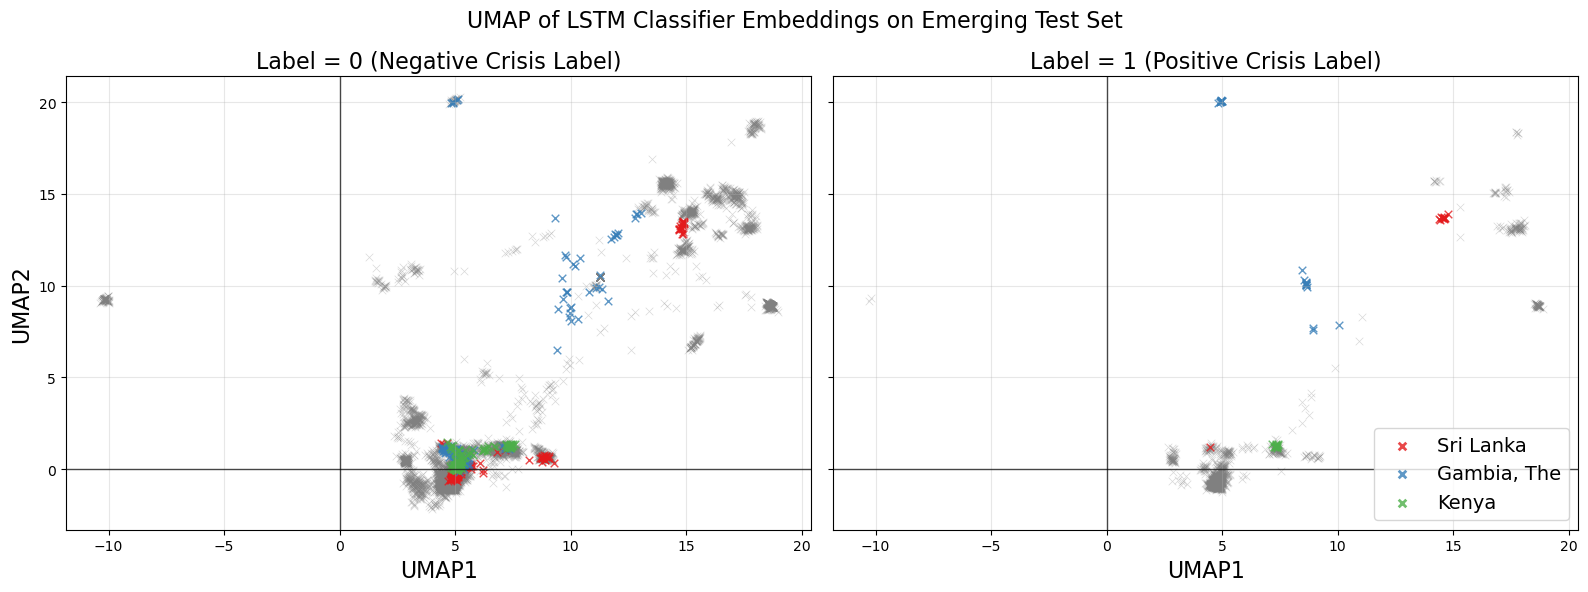

In [ ]:
# visualize emerging markets test embeddings
umap_emerging_embeddings = umap_unsupervised.transform(pd.DataFrame(query_embeddings))

query_region = pd.merge(add_query_df, iso, left_on='Country', right_on='name', how='left')
query_color_by = query_region['Country'].iloc[query_valid_indices].reset_index(drop=True)

umap_unsupervised.plot_feature_space(
    pd.DataFrame(umap_emerging_embeddings), labels=y_query_aligned,
    color_by=query_color_by,
    title="UMAP of LSTM Classifier Embeddings on Emerging Test Set",
)